In [1]:
import pandas as pd
import numpy as np
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch
import torch.nn.functional as F
from torch.optim import SGD, Adam, AdamW, RMSprop
from sklearn.metrics import classification_report, f1_score
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from IPython.display import clear_output
from tqdm.notebook import tqdm
from torch.optim.lr_scheduler import ExponentialLR

import random
import os

import seaborn as sns

sns.set_theme()

In [2]:
def set_seed(seed: int = 42) -> None:
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    # When running on the CuDNN backend, two further options must be set
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    # Set a fixed value for the hash seed
    os.environ["PYTHONHASHSEED"] = str(seed)
    print(f"Random seed set as {seed}")

set_seed(42)

Random seed set as 42


In [3]:
df = pd.read_csv('/content/cybersequrity.csv')

In [4]:
df.head()

,svcscan.fs_drivers,callbacks.ngeneric,psxview.not_in_eprocess_pool_false_avg,psxview.not_in_eprocess_pool,callbacks.nanonymous,psxview.not_in_session,psxview.not_in_pslist,psxview.not_in_pspcid_list,psxview.not_in_ethread_pool,psxview.not_in_csrss_handles,psxview.not_in_pslist_false_avg,psxview.not_in_pspcid_list_false_avg,psxview.not_in_deskthrd,psxview.not_in_ethread_pool_false_avg,psxview.not_in_session_false_avg,Class
0,26,8,0.0,0,0,2,0,0,0,4,0.000000,0.000000,6,0.000000,0.044444,1
1,26,8,0.0,0,0,5,3,3,3,7,0.073171,0.073171,9,0.073171,0.121951,1
2,26,8,0.0,0,0,9,7,7,7,11,0.152174,0.152174,13,0.152174,0.195652,1
3,26,8,0.0,0,0,3,1,1,2,6,0.022222,0.022222,9,0.044444,0.066667,1
4,26,8,0.0,0,0,2,0,0,0,4,0.000000,0.000000,6,0.000000,0.048780,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   svcscan.fs_drivers                      10000 non-null  int64  
 1   callbacks.ngeneric                      10000 non-null  int64  
 2   psxview.not_in_eprocess_pool_false_avg  10000 non-null  float64
 3   psxview.not_in_eprocess_pool            10000 non-null  int64  
 4   callbacks.nanonymous                    10000 non-null  int64  
 5   psxview.not_in_session                  10000 non-null  int64  
 6   psxview.not_in_pslist                   10000 non-null  int64  
 7   psxview.not_in_pspcid_list              10000 non-null  int64  
 8   psxview.not_in_ethread_pool             10000 non-null  int64  
 9   psxview.not_in_csrss_handles            10000 non-null  int64  
 10  psxview.not_in_pslist_false_avg         10000 non-null  flo

In [6]:
features, target = df.drop(columns = ['Class']), df['Class']

**Based partition of dataset set into train, val and test, by using sklearn, when splitting into val and train I used size 0.25, by this way I got the same shapes in test and val datasets.**

In [7]:
from sklearn.model_selection import train_test_split

X, X_test, y, y_test = train_test_split(features, target, test_size=0.2, stratify=target)

In [8]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.25, stratify=y)

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [10]:
X_val.shape == X_test.shape

True

**Creating Dataset class. Also I decided to add standartization into Dataset like transformation of data.**

In [11]:
class CyberSeqDataset(Dataset):
  def __init__(self,features: pd.DataFrame, target:pd.DataFrame, transforms:bool = False,
               train:bool = False, sc = None):
    self.transforms = transforms
    self.features = torch.tensor(features, dtype= torch.float32)
    self.target = torch.tensor(target.values.reshape(-1,1)).float()

  def __len__(self):
    return self.features.shape[0]

  def __getitem__(self, index:int):
    return self.features[index], self.target[index]

In [12]:
dataset_train = CyberSeqDataset(features=X_train, target=y_train)
dataset_validation = CyberSeqDataset(features=X_val, target = y_val)
dataset_test = CyberSeqDataset(features= X_test, target = y_test)

**Defined variable to select batch size. I want to make batch for validation bigger than in train.**

In [13]:
batch_size_train = 2048
batch_size_val = 2048

**Define dataloaders, I used count count of numworkers 2, because colab couldn't use more ;(**

In [14]:
dataloader_train = DataLoader(dataset_train, batch_size = batch_size_train, shuffle = True, num_workers=2)
dataloader_val = DataLoader(dataset_validation, batch_size=batch_size_val, shuffle = False, num_workers=2)
dataloader_test = DataLoader(dataset_test, batch_size=batch_size_val, shuffle=False, num_workers=2)

**NN model for this task, added parametr coutn of layers in nn, batch_norm_input - added batch normalization in input layer and also append parametr batch_norm_hidden - it's creating Batch normalization layer in hidden layers, dropout_hidden - parametr, when it's True append dropout layer into nn.**

In [15]:
class CyberSeqModel(nn.Module):
  def __init__(self,
               hidden_layers:list,
               batch_norm_input:bool = False,
               batch_norm_hidden: bool = False,
               dropout_hidden: bool = False,
               prob_dropout:float = 0.5,
               activation = nn.Sigmoid):
    super().__init__()
    self.batch_norm_input = batch_norm_input
    self.activation = activation()
    self.prob_dropout = prob_dropout
    self.hidden_layer = hidden_layers
    self.layers = []
    self.dropout_hidden = dropout_hidden

    for i in self.hidden_layer:
      self.layers.append(nn.LazyLinear(i))
      if batch_norm_hidden:
        self.layers.append(nn.BatchNorm1d(i))
      if dropout_hidden:
        self.layers.append(nn.Dropout(prob_dropout))
      self.layers.append(self.activation)

    self.layers.append(nn.Sigmoid())
    self.layers = nn.Sequential(*self.layers)

  def forward(self, features):
    pred = self.layers(features)
    return pred

In [16]:
loss_function = nn.BCELoss()

**Choosing device**

In [17]:
device = torch.device('cuda' if torch.cuda.is_available else 'cpu')
device

device(type='cuda')

**Define a train function (with scheduler) and eval function**

In [18]:
@torch.inference_mode()
def validation(model, mode = 'eval'):
  model.eval()

  dataloder = dataloader_val if mode == 'eval' else dataloader_test

  loss_epoch = 0
  num_epoch = 0
  pred_list = list()
  target_list = list()

  for features, targets in dataloder:
    pred = model(features.to(device))
    loss = loss_function(pred, targets.to(device))
    num = pred.shape[0]
    loss_epoch += loss.item() * num
    num_epoch += num

    pred_list += (pred >= 0.5).int().cpu().tolist()
    target_list += targets.cpu().numpy().tolist()



  f1 = f1_score(pred_list, target_list)

  return loss_epoch / num_epoch, f1

In [19]:
def train(model, optimizer, num_epoch = 100, eval_freq = 10):
  model.to(device)
  model.train()
  train_loss_history, eval_loss_history = [], []
  train_f1_history, eval_f1_history = [], []
  global_step = 0

  for epoch in tqdm(range(num_epoch)):
    for features, targets in dataloader_train:
      optimizer.zero_grad()
      pred = model(features.to(device))
      loss = loss_function(pred, targets.to(device))
      loss.backward()
      optimizer.step()

      labels = (pred >= 0.5).int().cpu().tolist()
      f1 = f1_score(labels, targets.cpu().numpy().tolist())

      train_loss_history.append((global_step, loss.item()))
      train_f1_history.append((global_step, f1))

      if global_step % eval_freq == 0:
        val_loss, val_f1 = validation(model)
        eval_loss_history.append((global_step, val_loss))
        eval_f1_history.append((global_step, val_f1))
        model.train()


      if global_step % 5 == 0:
        clear_output(True)
        plt.figure(figsize=(15, 5))

        plt.subplot(121)
        plt.plot(*zip(*train_loss_history), alpha=0.5, label='train_loss')
        if len(eval_loss_history):
          plt.plot(*zip(*eval_loss_history), color='red', label='eval_loss')
        plt.legend()

        plt.subplot(122)
        plt.plot(*zip(*train_f1_history), alpha=0.5, label='train_f1')
        if len(eval_f1_history):
          plt.plot(*zip(*eval_f1_history), color='red', label='eval_f1')
        plt.legend()
        plt.show()

      global_step += 1
  return model

In [20]:
list_of_hidden_layers = [64, 32, 16, 1]

model = CyberSeqModel(hidden_layers = list_of_hidden_layers)

In [21]:
device

device(type='cuda')

**Next I choose the best activation function for model**

In [22]:
optimizer = SGD(model.parameters())

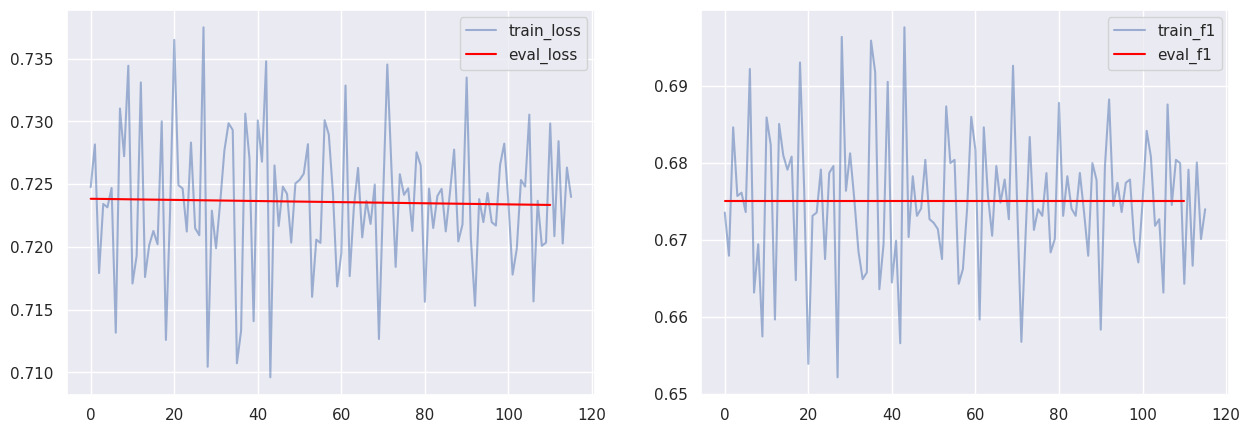

CyberSeqModel(
  (activation): Sigmoid()
  (layers): Sequential(
    (0): Linear(in_features=15, out_features=64, bias=True)
    (1): Sigmoid()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): Sigmoid()
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): Sigmoid()
    (6): Linear(in_features=16, out_features=1, bias=True)
    (7): Sigmoid()
    (8): Sigmoid()
  )
)

In [23]:
train(model, optimizer, num_epoch = 40)

In [24]:
validation(model)

(0.7233058214187622, 0.6750579662139782)

In [25]:
model_tan = CyberSeqModel(hidden_layers = list_of_hidden_layers, activation = nn.Tanh)

In [26]:
optimizer_tan = SGD(model_tan.parameters())

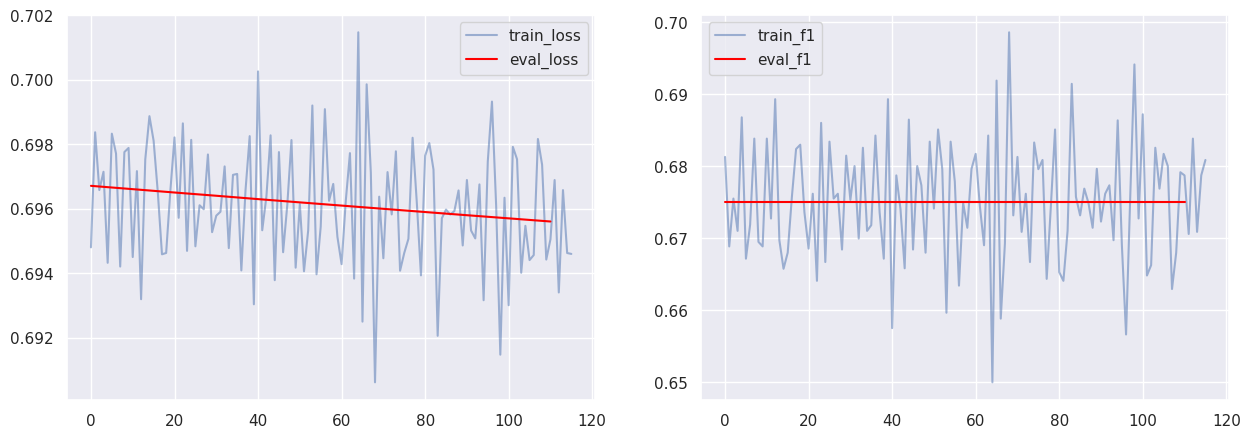

CyberSeqModel(
  (activation): Tanh()
  (layers): Sequential(
    (0): Linear(in_features=15, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): Tanh()
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): Tanh()
    (6): Linear(in_features=16, out_features=1, bias=True)
    (7): Tanh()
    (8): Sigmoid()
  )
)

In [27]:
train(model_tan, optimizer_tan, num_epoch = 40)

In [28]:
model_re = CyberSeqModel(hidden_layers = list_of_hidden_layers, activation = nn.ReLU)

In [29]:
optimizer_re = SGD(model_re.parameters())

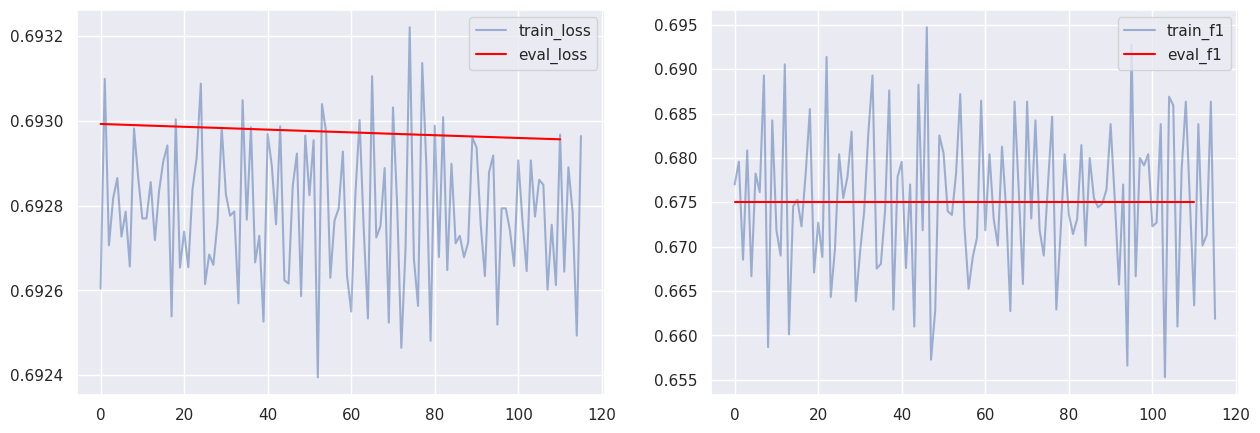

CyberSeqModel(
  (activation): ReLU()
  (layers): Sequential(
    (0): Linear(in_features=15, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): ReLU()
    (6): Linear(in_features=16, out_features=1, bias=True)
    (7): ReLU()
    (8): Sigmoid()
  )
)

In [30]:
train(model_re, optimizer_re, num_epoch = 40)

In [31]:
model_re_leak = CyberSeqModel(hidden_layers = list_of_hidden_layers, activation = nn.LeakyReLU)

In [32]:
optimizer_re_leak = SGD(model_re_leak.parameters())

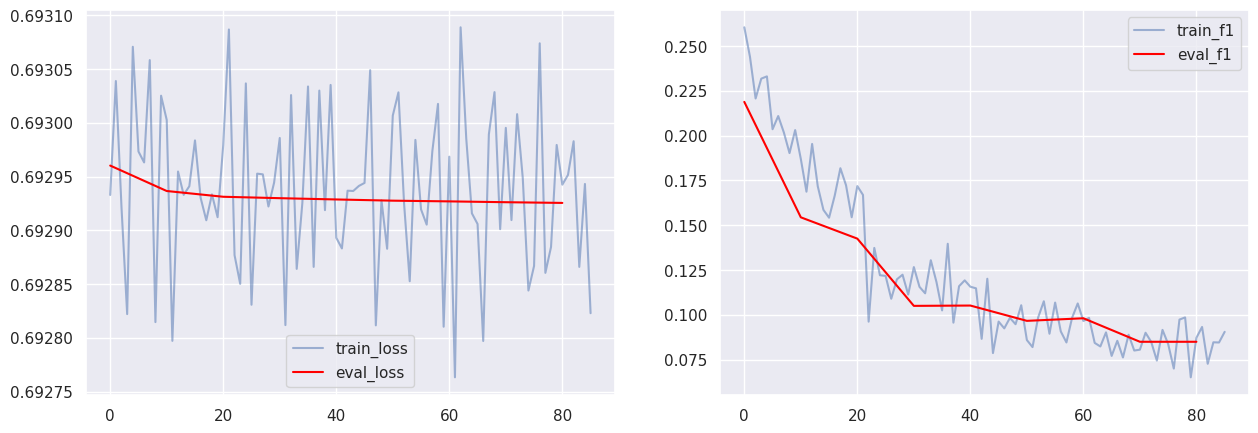

CyberSeqModel(
  (activation): LeakyReLU(negative_slope=0.01)
  (layers): Sequential(
    (0): Linear(in_features=15, out_features=64, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): LeakyReLU(negative_slope=0.01)
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): LeakyReLU(negative_slope=0.01)
    (6): Linear(in_features=16, out_features=1, bias=True)
    (7): LeakyReLU(negative_slope=0.01)
    (8): Sigmoid()
  )
)

In [33]:
train(model_re_leak, optimizer_re_leak, num_epoch=30)

In [34]:
validation(model)

(0.7233058214187622, 0.6750579662139782)

**Seems like on effect with others activation functions, next I want to try some optimizers**

In [35]:
model = CyberSeqModel(hidden_layers = list_of_hidden_layers, activation = nn.ReLU)

In [36]:
optimizer = SGD(model.parameters(), momentum =0.9)

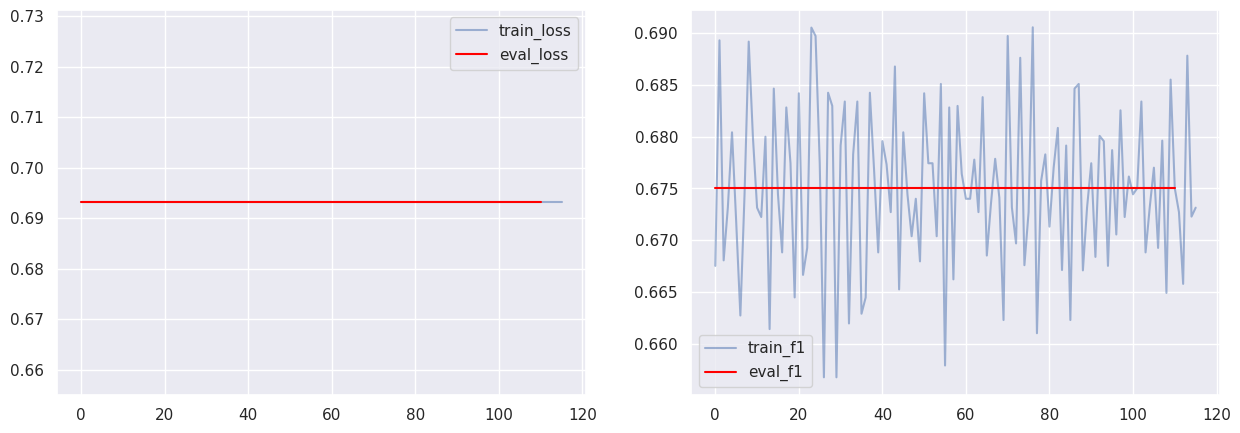

CyberSeqModel(
  (activation): ReLU()
  (layers): Sequential(
    (0): Linear(in_features=15, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): ReLU()
    (6): Linear(in_features=16, out_features=1, bias=True)
    (7): ReLU()
    (8): Sigmoid()
  )
)

In [37]:
train(model, optimizer, num_epoch=40)

**After applying SGD with momentum, got faster training**

In [38]:
model = CyberSeqModel(list_of_hidden_layers, activation = nn.ReLU)
optimizer = RMSprop(model.parameters())

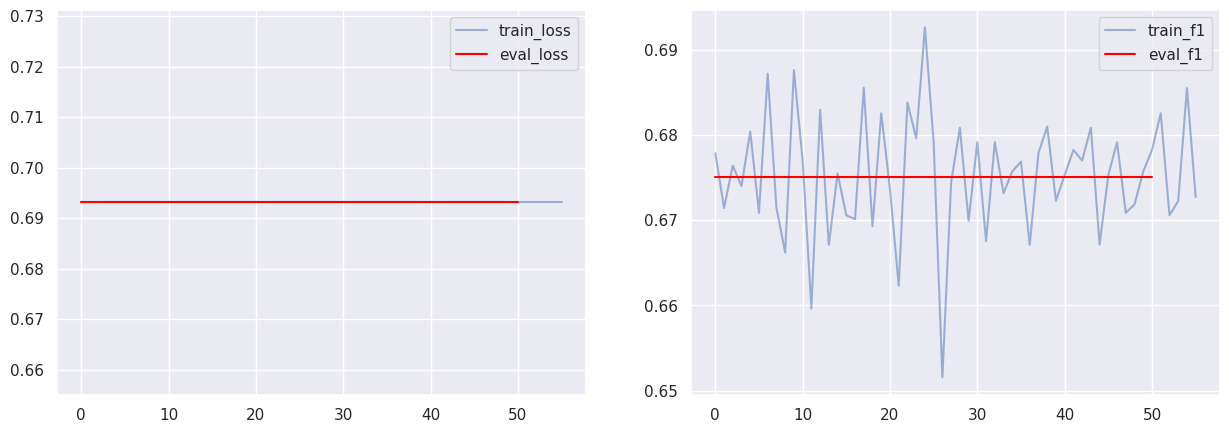

CyberSeqModel(
  (activation): ReLU()
  (layers): Sequential(
    (0): Linear(in_features=15, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): ReLU()
    (6): Linear(in_features=16, out_features=1, bias=True)
    (7): ReLU()
    (8): Sigmoid()
  )
)

In [39]:
train(model, optimizer, num_epoch=20)

**Got the fastest learning speed so far**

In [40]:
model = CyberSeqModel(hidden_layers = list_of_hidden_layers)
optimizer = Adam(model.parameters(), lr = 0.1)

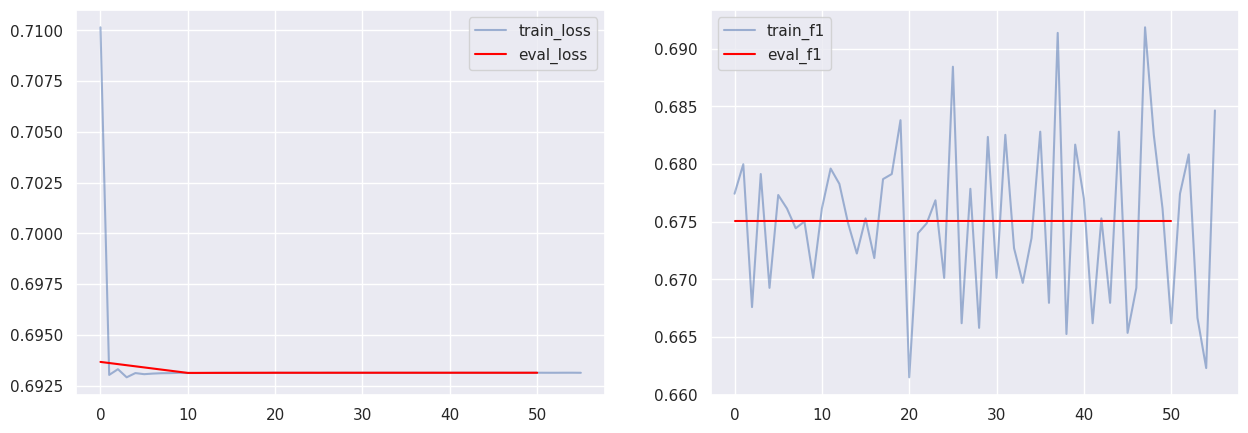

CyberSeqModel(
  (activation): Sigmoid()
  (layers): Sequential(
    (0): Linear(in_features=15, out_features=64, bias=True)
    (1): Sigmoid()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): Sigmoid()
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): Sigmoid()
    (6): Linear(in_features=16, out_features=1, bias=True)
    (7): Sigmoid()
    (8): Sigmoid()
  )
)

In [41]:
train(model, optimizer, num_epoch = 20)

In [42]:
model = CyberSeqModel(hidden_layers = list_of_hidden_layers)
optimizer = AdamW(model.parameters(), lr = 0.1)

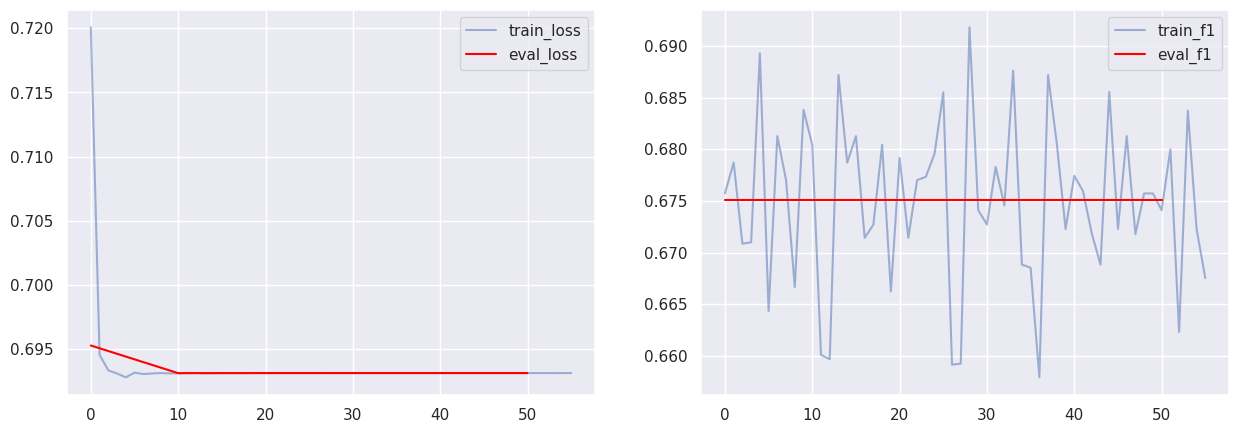

CyberSeqModel(
  (activation): Sigmoid()
  (layers): Sequential(
    (0): Linear(in_features=15, out_features=64, bias=True)
    (1): Sigmoid()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): Sigmoid()
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): Sigmoid()
    (6): Linear(in_features=16, out_features=1, bias=True)
    (7): Sigmoid()
    (8): Sigmoid()
  )
)

In [43]:
train(model, optimizer, num_epoch = 20)

**Adam and AdamW have the fastest learning rate, although they reach a plateau very quickly, it may be worth considering different model structures, however I will choose Adam as the optimizer**

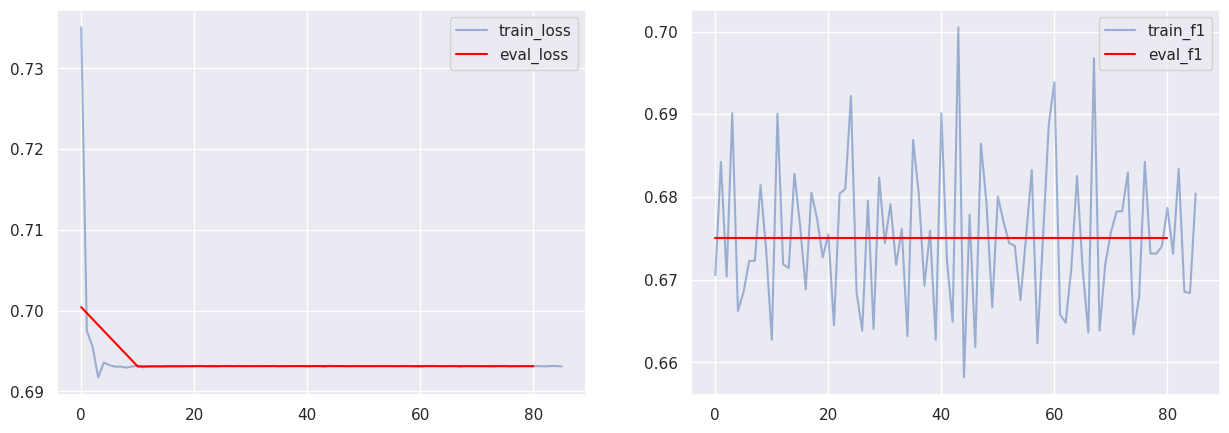

CyberSeqModel(
  (activation): Sigmoid()
  (layers): Sequential(
    (0): Linear(in_features=15, out_features=64, bias=True)
    (1): Sigmoid()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): Sigmoid()
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): Sigmoid()
    (6): Linear(in_features=16, out_features=1, bias=True)
    (7): Sigmoid()
    (8): Sigmoid()
  )
)

In [44]:
model = CyberSeqModel(hidden_layers = list_of_hidden_layers)
optimizer = AdamW(model.parameters(), lr = 0.1)
train(model, optimizer, num_epoch = 30)

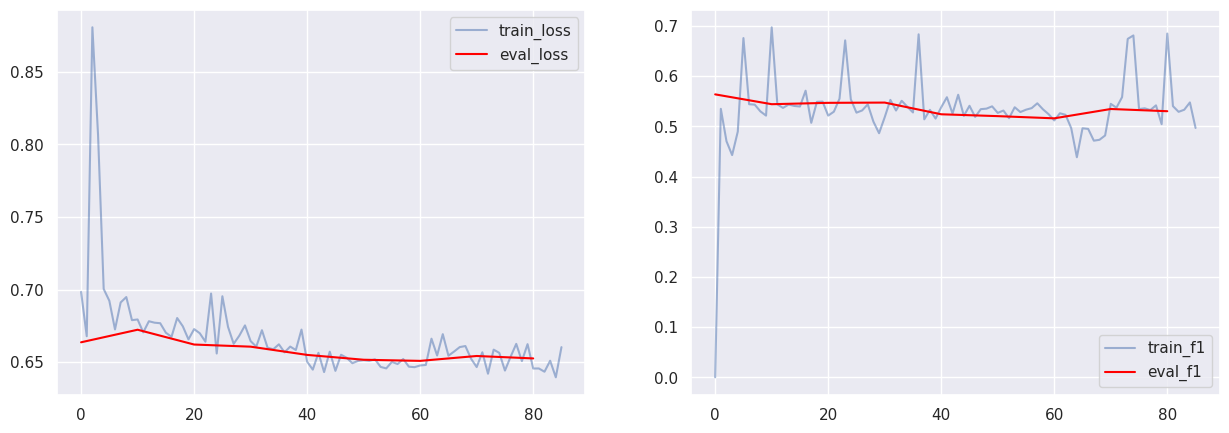

CyberSeqModel(
  (activation): Tanh()
  (layers): Sequential(
    (0): Linear(in_features=15, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): Tanh()
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): Tanh()
    (6): Linear(in_features=16, out_features=1, bias=True)
    (7): Tanh()
    (8): Sigmoid()
  )
)

In [45]:
model = CyberSeqModel(hidden_layers = list_of_hidden_layers, activation = nn.Tanh)
optimizer = AdamW(model.parameters(), lr = 0.1)
train(model, optimizer, num_epoch = 30)

In [46]:
model = CyberSeqModel(hidden_layers = list_of_hidden_layers, activation = nn.ReLU)
optimizer = AdamW(model.parameters(), lr = 0.1)

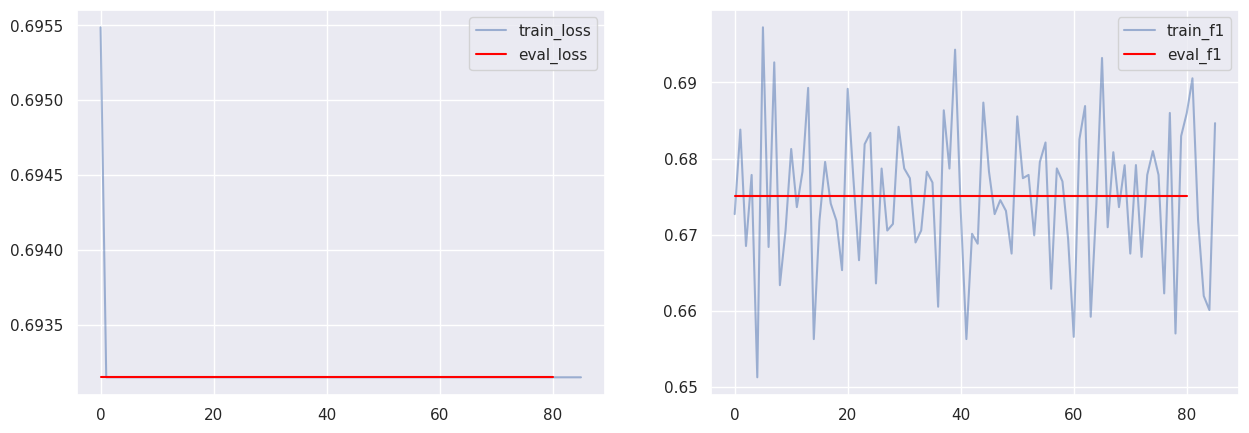

CyberSeqModel(
  (activation): ReLU()
  (layers): Sequential(
    (0): Linear(in_features=15, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): ReLU()
    (6): Linear(in_features=16, out_features=1, bias=True)
    (7): ReLU()
    (8): Sigmoid()
  )
)

In [47]:
train(model, optimizer, num_epoch = 30)

In [48]:
model = CyberSeqModel(hidden_layers = list_of_hidden_layers, activation = nn.LeakyReLU)
optimizer = AdamW(model.parameters(), lr = 0.1)

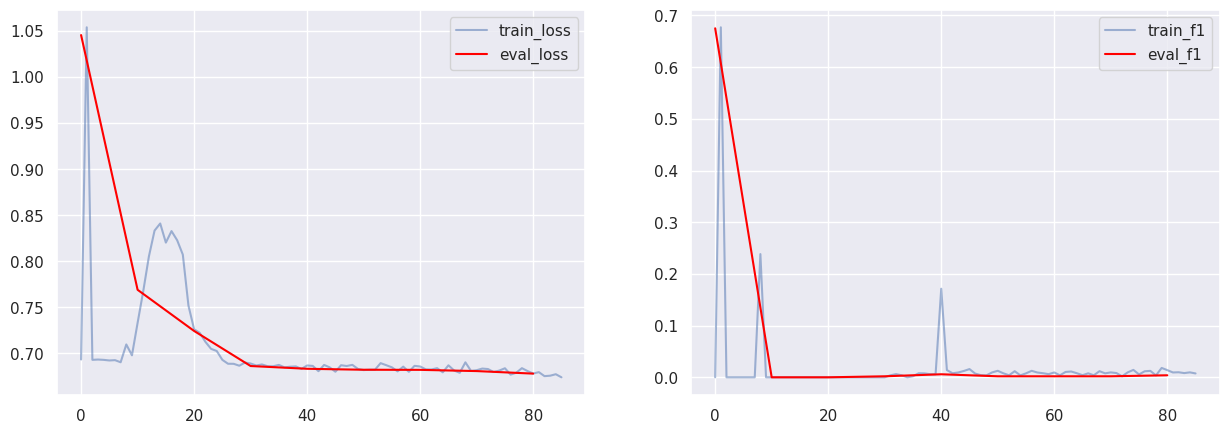

CyberSeqModel(
  (activation): LeakyReLU(negative_slope=0.01)
  (layers): Sequential(
    (0): Linear(in_features=15, out_features=64, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): LeakyReLU(negative_slope=0.01)
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): LeakyReLU(negative_slope=0.01)
    (6): Linear(in_features=16, out_features=1, bias=True)
    (7): LeakyReLU(negative_slope=0.01)
    (8): Sigmoid()
  )
)

In [49]:
train(model, optimizer, num_epoch = 30)

**As result I want to choose ReLU, because the loss function better converge**

In [50]:
model = CyberSeqModel(list_of_hidden_layers, activation = nn.ReLU, batch_norm_input = True, dropout_hidden = True)
optimizer = Adam(model.parameters(), lr = 0.01)

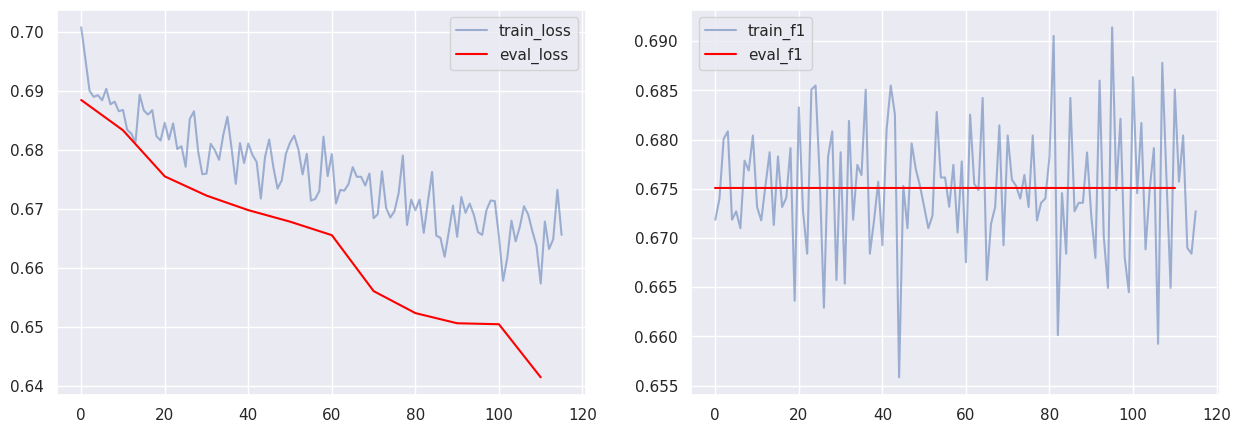

CyberSeqModel(
  (activation): ReLU()
  (layers): Sequential(
    (0): Linear(in_features=15, out_features=64, bias=True)
    (1): Dropout(p=0.5, inplace=False)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): Dropout(p=0.5, inplace=False)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=16, bias=True)
    (7): Dropout(p=0.5, inplace=False)
    (8): ReLU()
    (9): Linear(in_features=16, out_features=1, bias=True)
    (10): Dropout(p=0.5, inplace=False)
    (11): ReLU()
    (12): Sigmoid()
  )
)

In [51]:
train(model, optimizer, num_epoch = 40)

**I see that loss function decreasing every time, now I want to try model without dropout**

In [52]:
model = CyberSeqModel(hidden_layers = list_of_hidden_layers, batch_norm_input = True, activation = nn.ReLU)
optimizer = Adam(model.parameters(), lr = 0.01)

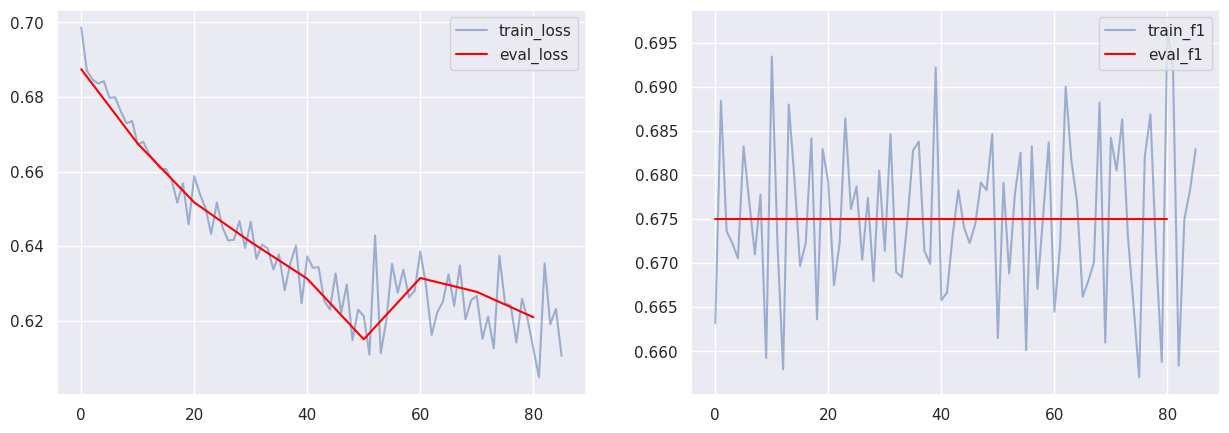

CyberSeqModel(
  (activation): ReLU()
  (layers): Sequential(
    (0): Linear(in_features=15, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): ReLU()
    (6): Linear(in_features=16, out_features=1, bias=True)
    (7): ReLU()
    (8): Sigmoid()
  )
)

In [53]:
train(model, optimizer, num_epoch = 30)

**For now I got the best result with first batch norm**

**With decreasing probability in dropout layer I got worse results, maybe it happends because of dropping layers model is overfitted. Try to use higher value of probability**

In [54]:
model = CyberSeqModel(hidden_layers = list_of_hidden_layers, activation = nn.ReLU, batch_norm_input = True, prob_dropout = 0.9,  dropout_hidden = True)
optimizer = Adam(model.parameters(), lr = 0.001)

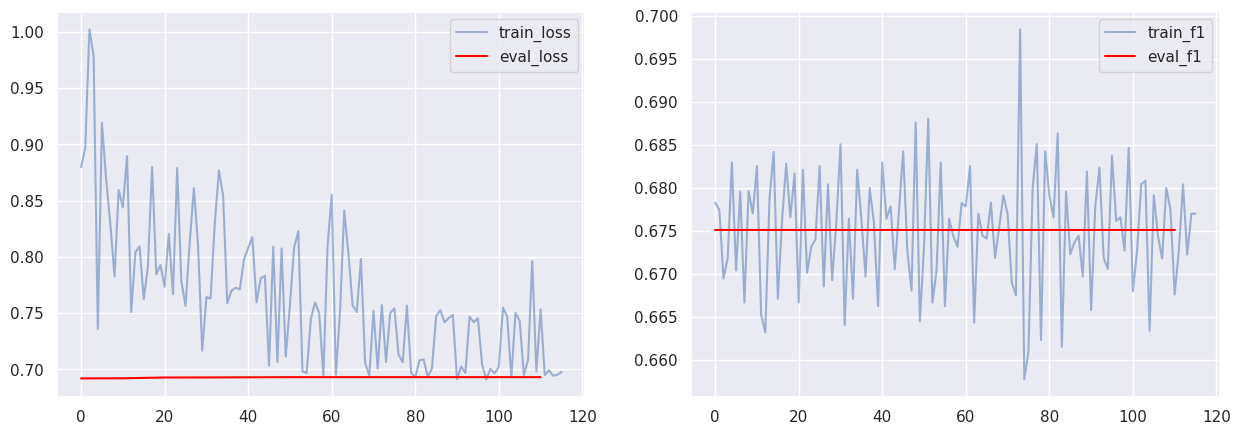

CyberSeqModel(
  (activation): ReLU()
  (layers): Sequential(
    (0): Linear(in_features=15, out_features=64, bias=True)
    (1): Dropout(p=0.9, inplace=False)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): Dropout(p=0.9, inplace=False)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=16, bias=True)
    (7): Dropout(p=0.9, inplace=False)
    (8): ReLU()
    (9): Linear(in_features=16, out_features=1, bias=True)
    (10): Dropout(p=0.9, inplace=False)
    (11): ReLU()
    (12): Sigmoid()
  )
)

In [55]:
train(model, optimizer, num_epoch = 40)

In [56]:
model = CyberSeqModel(hidden_layers = list_of_hidden_layers, activation = nn.ReLU, batch_norm_input = True, prob_dropout = 0.9,  dropout_hidden = True)
optimizer = Adam(model.parameters(), lr = 0.001)

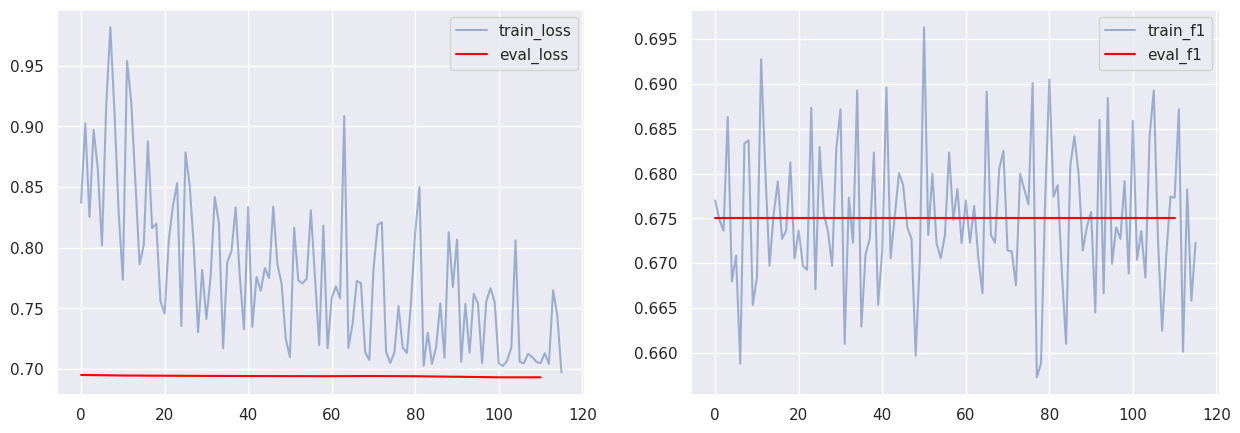

CyberSeqModel(
  (activation): ReLU()
  (layers): Sequential(
    (0): Linear(in_features=15, out_features=64, bias=True)
    (1): Dropout(p=0.9, inplace=False)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): Dropout(p=0.9, inplace=False)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=16, bias=True)
    (7): Dropout(p=0.9, inplace=False)
    (8): ReLU()
    (9): Linear(in_features=16, out_features=1, bias=True)
    (10): Dropout(p=0.9, inplace=False)
    (11): ReLU()
    (12): Sigmoid()
  )
)

In [57]:
train(model, optimizer, num_epoch = 40)

**As a result I want to train model with ReLU, Adam is optimizer and BatchNorm I want to apply only for first layer, also I want to change structure of model**

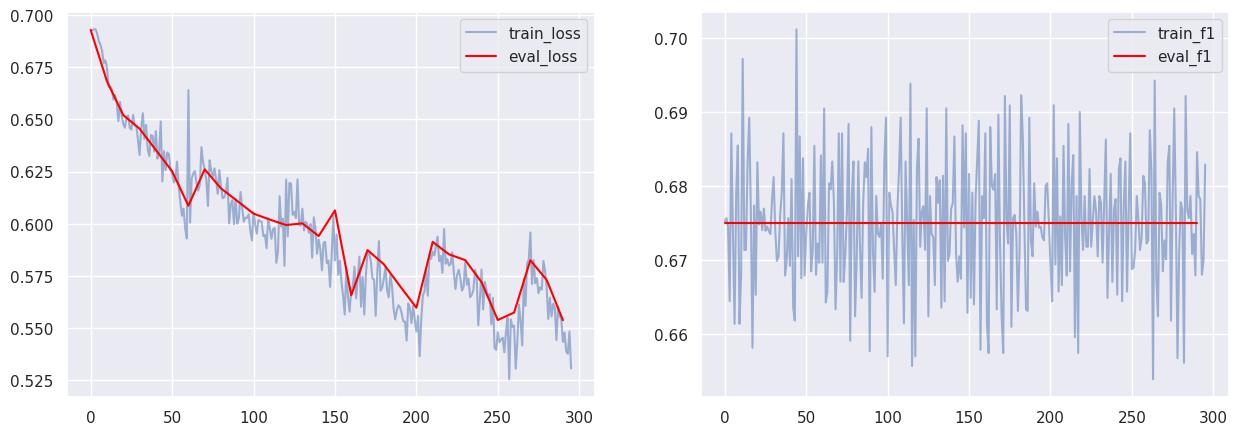

CyberSeqModel(
  (activation): ReLU()
  (layers): Sequential(
    (0): Linear(in_features=15, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): ReLU()
    (6): Linear(in_features=16, out_features=1, bias=True)
    (7): ReLU()
    (8): Sigmoid()
  )
)

In [58]:
list_of_hidden_layers = [64, 32, 16, 1]

model = CyberSeqModel(hidden_layers = list_of_hidden_layers, batch_norm_input = True, activation = nn.ReLU)
optimizer = Adam(model.parameters(), lr = 0.01)

train(model, optimizer, num_epoch = 100)

In [59]:
validation(model)

(0.5486562252044678, 0.6750579662139782)

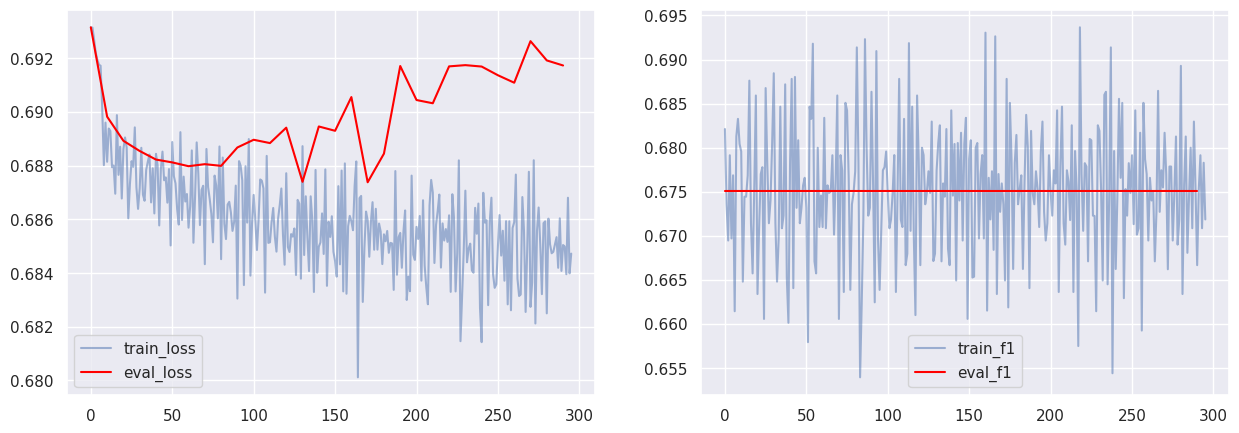

CyberSeqModel(
  (activation): ReLU()
  (layers): Sequential(
    (0): Linear(in_features=15, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=1, bias=True)
    (5): ReLU()
    (6): Sigmoid()
  )
)

In [60]:
list_of_hidden_layers = [32, 16, 1]

model = CyberSeqModel(hidden_layers = list_of_hidden_layers, batch_norm_input = True, activation = nn.ReLU)
optimizer = Adam(model.parameters(), lr = 0.01)

train(model, optimizer, num_epoch = 100)

In [61]:
validation(model)

(0.69287109375, 0.6750579662139782)

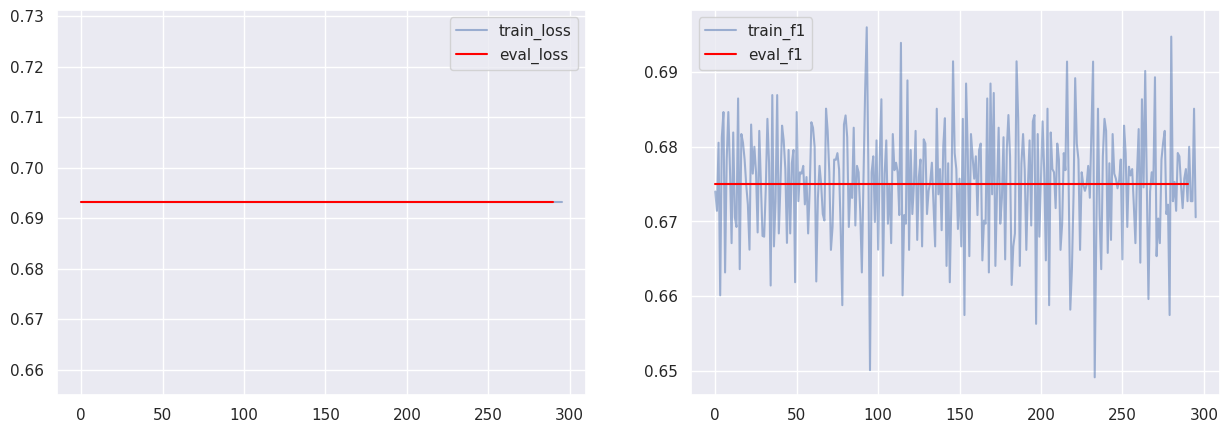

CyberSeqModel(
  (activation): ReLU()
  (layers): Sequential(
    (0): Linear(in_features=15, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=16, bias=True)
    (7): ReLU()
    (8): Linear(in_features=16, out_features=1, bias=True)
    (9): ReLU()
    (10): Sigmoid()
  )
)

In [62]:
list_of_hidden_layers = [128, 64, 32, 16, 1]

model = CyberSeqModel(hidden_layers = list_of_hidden_layers, batch_norm_input = True, activation = nn.ReLU)
optimizer = Adam(model.parameters(), lr = 0.01)

train(model, optimizer, num_epoch = 100)

In [63]:
validation(model)

(0.6931471824645996, 0.6750579662139782)

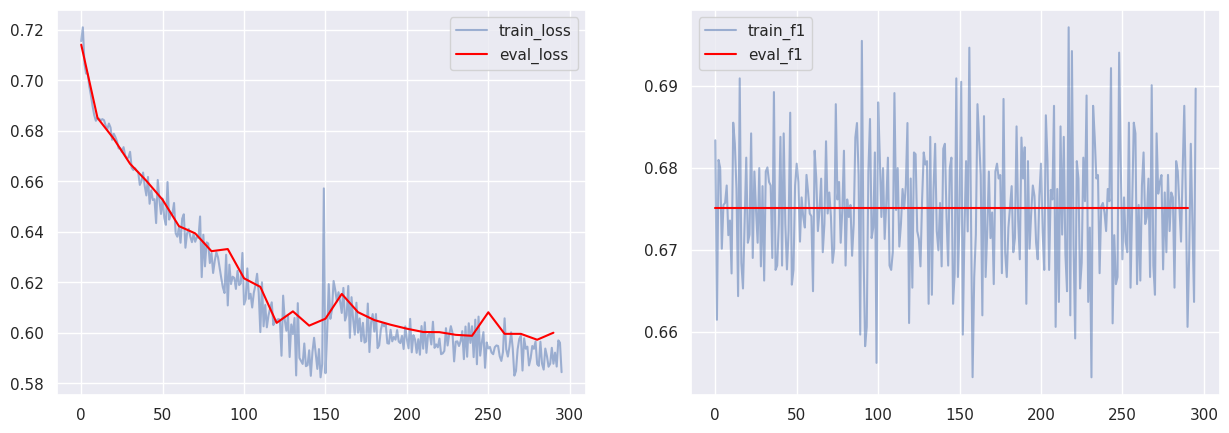

CyberSeqModel(
  (activation): ReLU()
  (layers): Sequential(
    (0): Linear(in_features=15, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=8, bias=True)
    (5): ReLU()
    (6): Linear(in_features=8, out_features=4, bias=True)
    (7): ReLU()
    (8): Linear(in_features=4, out_features=1, bias=True)
    (9): ReLU()
    (10): Sigmoid()
  )
)

In [64]:
list_of_hidden_layers = [32, 16, 8, 4, 1]

model = CyberSeqModel(hidden_layers = list_of_hidden_layers, batch_norm_input = True, activation = nn.ReLU)
optimizer = Adam(model.parameters(), lr = 0.01)

train(model, optimizer, num_epoch = 100)

In [65]:
validation(model)

(0.5975742340087891, 0.6750579662139782)

**Model with structure list_of_hidden_layers = list_of_hidden_layers =   [32, 16, 1], return the best result, the model can be trained over 100 epochs in the long run, so it's final version of model**

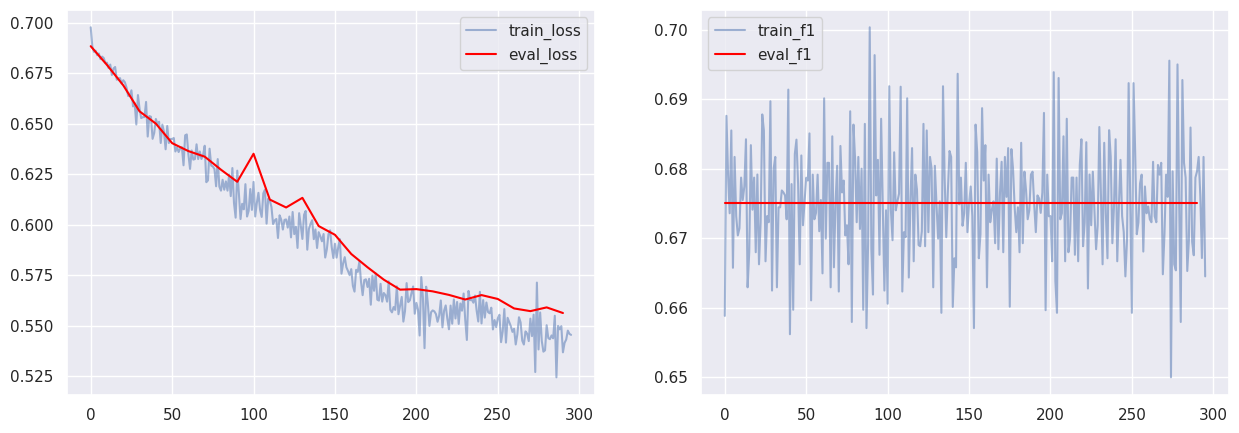

CyberSeqModel(
  (activation): ReLU()
  (layers): Sequential(
    (0): Linear(in_features=15, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=1, bias=True)
    (5): ReLU()
    (6): Sigmoid()
  )
)

In [66]:
list_of_hidden_layers =  [32, 16, 1]

model = CyberSeqModel(hidden_layers = list_of_hidden_layers, batch_norm_input = True, activation = nn.ReLU)
optimizer = Adam(model.parameters(), lr = 0.01)

train(model, optimizer, num_epoch = 100)

In [67]:
validation(model)

(0.5548900365829468, 0.6750579662139782)

In [68]:
all_preds = []
all_labels = []

model.eval()

with torch.no_grad():
  for x, targets in dataloader_test:
    x, targets = x.to(device), targets.to(device)
    preds = model(x)
    preds = (preds > 0.5)

    all_preds.extend(preds.cpu().numpy())
    all_labels.extend(targets.cpu().numpy())

report = classification_report(all_labels, all_preds)
report

'              precision    recall  f1-score   support\n\n         0.0       0.73      0.87      0.79       981\n         1.0       0.85      0.68      0.76      1019\n\n    accuracy                           0.78      2000\n   macro avg       0.79      0.78      0.77      2000\nweighted avg       0.79      0.78      0.77      2000\n'